
# **Türkiye Ulusal Gözlemevleri Bünyesindeki Erzurum DAG Yerleşkesi ve Antalya TUG Yerleşkesi için Gece Işıklarının Analizi**

## **Eğitim ve Uygulama Serisi - Bölüm 1: Yer Tabanlı SQM Ölçümleri ve Gökyüzü Kalitesinin Değerlendirilmesi**

- Bu eğitim serisi, **TÜBİTAK** 3501 Kariyer Geliştirme Programı kapsamında desteklenen **"124F297"** numaralı proje çerçevesinde geliştirilmiştir.

- **Dokümanı Hazırlayanlar: Dr. Kazım Kaba, Dr. Funda Aksoy, Doç. Dr. İlham Nasıroğlu, Fethullah Polat, Sima Aydın, Rabia Beyza Türkmen, Yusuf Sağlam, Prof. Dr. Cahit Yeşilyaprak, Prof. Dr. H. Mustafa Kandırmaz**

- Bu notebook dosyasında yer alan bazı analiz yaklaşımları, projeksiyon ve modelleme adımları **Kaba vd. (2026b)** tarafından yürütülen güncel araştırma çalışmaları temel alınarak kurgulanmıştır.

- Projemizin bilimsel temelini ve yer gerçekliği doğrulamalarını oluşturan yer tabanlı gökyüzü kalitesi ölçümlerinin analizine hoş geldiniz. Bu ilk uygulama dosyasında, saha verilerinin işlenmesi ve değerlendirilmesi adımlarını inceleyeceğiz.

- Astronomik yer seçimi testlerinde ve ışık kirliliği çalışmalarında endüstri standardı olarak kabul edilen SQM (Sky Quality Meter) cihazı, gökyüzünün karanlık derecesini logaritmik bir ölçekte kadir bölü açısaniye kare ($mag/arcsec^2$) birimiyle ölçmektedir. Bu birim, gökyüzünün belirli bir alanının yapay ışık kaynakları veya doğal göksel parlamalar nedeniyle ne derece aydınlandığını gösterir; değer büyüdükçe gökyüzü daha karanlık, küçüldükçe daha kirli (parlak) kabul edilir.

- Bu notebook kapsamında, 2025 yılı yaz aylarında (Temmuz ve Ağustos) Türkiye'nin iki büyük gözlemevine ev sahipliği yapan Antalya ve Erzurum bölgelerinde, astronomik gecelerde (Güneş ufkun $18^0$'nin altında olduğu, bulutsuz ve Ay'ın olmadığı evrelerde) gerçekleştirilen sistematik saha ölçüm verilerini Python ortamına aktaracağız.

- Veri setlerimizi temizleyecek, Bortle ölçeğine göre sınıflandıracak ve iki farklı coğrafi ve topoğrafik bölgenin noktasal gökyüzü kalite profillerini istatistiksel ve grafiksel olarak karşılaştıracağız.



## **1.1 SQM Ölçüm Metodolojisi**

Yer tabanlı gökyüzü kalitesi ölçümlerinin uluslararası standartlara uygun ve uydu gözlemleriyle radyometrik olarak karşılaştırılabilir olmasını sağlamak amacıyla saha çalışmaları sırasında şu ölçüm prosedürü titizlikle uygulanmıştır:

- Unihedron SQM-LU-DL cihazının merceği her istasyonda temizlenmiş, cihaz yerden 2 metre yükseklikteki bir üçayağa monte edilerek zenit (tam tepe) doğrultusuna yönlendirilmiştir.

- Kentsel ortamlarda, sokak lambalarının doğrudan sensör merceğine yansımasıyla oluşan yakın alan parlamalarını önlemek amacıyla, ölçümler ışık kaynağından en az 20 metre uzaklıkta yapılmıştır.

- Ölçümler yalnızca Güneş ufkun en az $-18^0$ altında olduğu astronomik gecelerde, bulutsuz gökyüzünde ve Ay'ın olmadığı evrelerde gerçekleştirilmiştir.

- Ölçümler yaklaşık Antalya'da 21:30–04:30, Erzurum'da 21:30–03:30 saat arlaığında gerçekleştirilmiştir.

- Her ölçüm noktasında, aralarında 20 saniye bulunan ardışık 12 ölçüm kaydedilmiştir.

- İlk iki ölçüm, sensörün ısınma/stabilizasyon hatalarını ve geçici atmosferik gürültüleri filtrelemek amacıyla elenmiştir.

- Geriye kalan kararlı durumdaki 10 ölçümün aritmetik ortalaması alınarak, o istasyonun nihai gece gökyüzü parlaklık değeri ($mag/arcsec^2$) hesaplanmış ve arşivlenmiştir.



## **1.2 Yer Tabanlı SQM Verilerinin Ön İşlemleri**

- Saha çalışmaları sırasında her bir örnekleme istasyonunda kaydedilen ham ölçümler, Unihedron cihaz yazılımı tarafından üretilen ayrık .dat formatındaki dosyalarda saklanmaktadır. Bu ham dosyalar; ölçüm yapılan istasyonun coğrafi konum bilgilerini (enlem, boylam, rakım), ölçüm anındaki ortam sıcaklığını ve saniye bazlı 12 adet ardışık SQM kaydını barındıran zengin bir meta veri yapısına sahiptir.

- Bu bölümde; Antalya, Erzurum ve TİKE referans bölgelerinde kaydedilen bu ayrık ham dosyaları Python ortamına aktaracağız. Her bir istasyonun meta verileri otomatik olarak ayıklanacak, ölçüm protokolüne uygun şekilde ilk iki gürültülü kaydı filtreleyecek, geriye kalan kararlı 10 okumadan istatistiksel özetleri (ortalama, medyan, minimum ve maksimum gökyüzü parlaklığı değerlerini) hesaplayacak ve her bölge için tek bir bütünleşik veri tablosunu txt formatında birleştireceğiz.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import pandas as pd
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# Ham verilerin ve çıktıların kaydedileceği ana dizin yolunu tanımlıyoruz
kaynak_dizin = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025'

# İşlenecek üç farklı hedef bölgeyi bir liste altında tanımlıyoruz
hedef_bolgeler = ['ANTALYA', 'ERZURUM', 'TIKE']

# Tüm bölgeleri sırasıyla döngüye alarak ardışık olarak işliyoruz
for bolge in hedef_bolgeler:
    print('='*80)
    print(f"{bolge} bölgesi için ham *.dat dosyaları aranıyor...")
    
    # İlgili bölge klasöründeki alt klasörlerde yer alan tüm *.dat dosyalarını listeliyoruz
    kaynak_dosyalar = glob.glob(os.path.join(kaynak_dizin, bolge, '*', '*.dat'))
    print(f"Toplam {len(kaynak_dosyalar)} adet ham ölçüm dosyası tespit edildi.")
    
    if len(kaynak_dosyalar) == 0:
        print(f"UYARI: {bolge} klasöründe işlenecek dosya bulunamadı, sonraki bölgeye geçiliyor.")
        continue
        
    # Bölgeye ait bütünleşik verilerin toplanacağı boş bir DataFrame şeması oluşturuyoruz
    tum_konum_verileri = pd.DataFrame(columns=[
        'Konum', 'Zaman (UTC)', 'Enlem (Derece)', 'Boylam (Derece)', 'Rakım (m)',
        'Ortalama_Sıcaklık (Celsius)', 'Minimum_MPSAS (mag/arcsec^2)', 'Ortalama_MPSAS (mag/arcsec^2)',
        'Medyan_MPSAS (mag/arcsec^2)', 'Maksimum_MPSAS (mag/arcsec^2)'
    ])
    
    # Tespit edilen tüm *.dat dosyalarını tek tek döngüye sokuyoruz
    for dosya_ismi in kaynak_dosyalar:
        # Ölçüm yapılan konumların dosya içerisinde yorum satırı (#) olarak bulunan meta verilerini okuyoruz
        with open(dosya_ismi, 'r') as dosya:
            satirlar = dosya.readlines()
            
            # Standart SQM meta veri indekslerinden konum, koordinat ve zaman bilgilerini ayıklıyoruz
            konum_ismi = satirlar[7].split(':')[1][1:-1]
            enlem, boylam, rakim = satirlar[8].split(':')[1].split(',')
            olcum_zamani = pd.to_datetime(':'.join(satirlar[27].split(':')[1:]))
        
        # '*.dat' dosyalarındaki saniye bazlı 12 ardışık sqm ölçümünü okuyoruz
        olcumler = pd.read_csv(dosya_ismi, comment='#', header=None, delimiter=';')
        
        # Ölçüm protokolüne uygun olarak ilk iki gürültülü veriyi çıkarıyoruz (3. satırdan itibaren alıyoruz)
        veri = olcumler.iloc[2:, :].dropna()
        
        # Kararlı durumdaki 10 ölçüm üzerinden istatistiksel parametreleri hesaplıyoruz
        olcum_sıcaklik = round(veri.iloc[:, 2].mean(), 2)
        olcum_min = round(veri.iloc[:, 5].min(), 2)
        olcum_max = round(veri.iloc[:, 5].max(), 2)
        olcum_ort = round(veri.iloc[:, 5].mean(), 2)
        olcum_med = round(veri.iloc[:, 5].median(), 2)
        
        # Hesaplanan özet verileri bir satır halinde düzenliyoruz
        veri_ozeti = [
            konum_ismi, olcum_zamani, float(enlem), float(boylam), int(rakim),
            olcum_sıcaklik, olcum_min, olcum_ort, olcum_med, olcum_max
        ]
        
        # Satırı ana tablomuza ekliyoruz
        tum_konum_verileri.loc[len(tum_konum_verileri)] = veri_ozeti
    
    # Zaman serisinin kronolojik doğruluğunu sağlamak için ölçüm tarihine göre sıralıyoruz
    tum_konum_verileri = tum_konum_verileri.sort_values(by=['Zaman (UTC)'])
    
    # Enlem ve boylam sütunlarını kaydetmeden önce özel olarak virgülden sonra 6 hane olacak şekilde metne dönüştürüyoruz.
    tum_konum_verileri['Enlem (Derece)'] = tum_konum_verileri['Enlem (Derece)'].map(lambda x: f"{x:.6f}")
    tum_konum_verileri['Boylam (Derece)'] = tum_konum_verileri['Boylam (Derece)'].map(lambda x: f"{x:.6f}")
    
    # Konum bilgisini indeks olarak ayarlıyoruz
    tum_konum_verileri = tum_konum_verileri.set_index(['Konum'])
    
    # Çıktı dosya adını dinamik olarak tanımlıyoruz
    cikti_yolu = os.path.join(kaynak_dizin, f"SQM_DUZENLI_VERI_{bolge}.txt")
    
    # Tabloyu kaydediyoruz.
    tum_konum_verileri.to_csv(cikti_yolu, sep='\t', encoding='utf-8-sig', float_format='%.2f')
    print(f"Bölge verileri başarıyla birleştirildi ve kaydedildi: {cikti_yolu}")

print('='*80)
print("Tüm bölgeler için SQM veri birleştirme işlemleri başarıyla tamamlanmıştır.")
print('='*80)

# En son işlenen bölgeye (TİKE) ait tablonun ilk 10 satırını Notebook üzerinde önizliyoruz
tum_konum_verileri.head(10)


ANTALYA bölgesi için ham *.dat dosyaları aranıyor...
Toplam 52 adet ham ölçüm dosyası tespit edildi.
Bölge verileri başarıyla birleştirildi ve kaydedildi: E:\=PROJELER\=TUBITAK_3501_2024\veri\sqm\SQM_VERI_2025\SQM_DUZENLI_VERI_ANTALYA.txt
ERZURUM bölgesi için ham *.dat dosyaları aranıyor...
Toplam 63 adet ham ölçüm dosyası tespit edildi.
Bölge verileri başarıyla birleştirildi ve kaydedildi: E:\=PROJELER\=TUBITAK_3501_2024\veri\sqm\SQM_VERI_2025\SQM_DUZENLI_VERI_ERZURUM.txt
TIKE bölgesi için ham *.dat dosyaları aranıyor...
Toplam 28 adet ham ölçüm dosyası tespit edildi.
Bölge verileri başarıyla birleştirildi ve kaydedildi: E:\=PROJELER\=TUBITAK_3501_2024\veri\sqm\SQM_VERI_2025\SQM_DUZENLI_VERI_TIKE.txt
Tüm bölgeler için SQM veri birleştirme işlemleri başarıyla tamamlanmıştır.


,Zaman (UTC),Enlem (Derece),Boylam (Derece),Rakım (m),Ortalama_Sıcaklık (Celsius),Minimum_MPSAS (mag/arcsec^2),Ortalama_MPSAS (mag/arcsec^2),Medyan_MPSAS (mag/arcsec^2),Maksimum_MPSAS (mag/arcsec^2)
Konum,,,,,,,,,
ATA50O,2025-07-23 21:11:30.929,39.902969,41.243670,1861,19.66,18.93,18.93,18.93,18.93
KYSAVM,2025-08-19 18:11:13.013,38.721837,35.526997,1063,28.77,17.87,17.87,17.87,17.88
YGNBRC,2025-08-19 18:31:55.050,38.718105,35.491695,1064,25.61,17.03,17.14,17.16,17.22
KURSUN,2025-08-19 18:46:30.390,38.722685,35.486408,1057,26.10,16.76,16.78,16.79,16.80
MSNPAR,2025-08-19 19:05:26.235,38.722590,35.484243,1060,24.13,17.21,17.22,17.21,17.27
KAYADA,2025-08-19 19:22:28.927,38.735234,35.480546,1072,25.40,17.67,17.68,17.68,17.70
BEYBUL,2025-08-19 19:35:51.023,38.749488,35.472815,1051,24.57,17.95,17.95,17.95,17.96
KAPDKY,2025-08-19 20:43:09.467,38.635392,34.889783,1179,21.89,19.68,19.69,19.69,19.69
GOREME,2025-08-19 21:17:05.899,38.643454,34.830520,1104,21.82,18.50,18.53,18.54,18.55



- Düzenlenmiş SQM verilerini **"gece-isiklari-analizi/veri/sqm"** dizininde **"SQM_DUZENLI_VERI_*.txt"** dosyalarında bulabilirsiniz.



## **1.3 Çalışma Alanı: SQM Ölçüm Noktaları**

- Türkiye'nin en önemli iki ulusal astronomi ve uzay bilimleri araştırma tesisi olan DAG ve TUG'a ev sahipliği yapmaları nedeniyle, projenin ana araştırma sahaları olarak Erzurum ve Antalya illeri seçilmiştir.

- Bu iller, bünyelerindeki gözlemevlerinin gökyüzü kalitesini doğrudan etkileme potansiyeline sahip, birbiriyle kontrast oluşturan topoğrafik, iklimsel, demografik ve sosyo-ekonomik yapılara sahiptir. Bu durum, kentsel morfolojinin, nüfus yoğunluğunun ve aydınlatma altyapılarının gece gökyüzü kalitesi üzerindeki etkilerini karşılaştırmalı olarak analiz etmek için ideal bir zemin sunmaktadır.

- Ölçüm konumlarının belirlenmesinde, yapay aydınlatmanın en yoğun olduğu kentsel çekirdeklerden (fotopik/mezopik rejimler), gözlemevlerini çevreleyen mutlak karanlıktaki dağlık alanlara (skotopik rejim) kadar uzanan radyometrik gradyanın homojen bir temsilini sağlamak amacı benimsenmiştir. Bu strateji kapsamında:

    - Antalya (TUG Bölgesi): Yoğun kentleşmiş ve turizm odaklı kıyı şeridi ile Toros Dağları'nın karanlık alanları arasındaki keskin kontrastı yakalayan 52 lokasyonda,

    - Erzurum (DAG Bölgesi): Kompakt radyal kentsel merkez ile Palandöken Dağları'nın yüksek rakımlı kırsal art bölgesini kapsayan 63 lokasyonda SQM ölçümleri gerçekleştirilmiştir.

    - TİKE Referans İstasyonları (İç Anadolu): Ayrıca, ışık kirliliğinin son on yıldaki zamansal değişimini izlemek amacıyla, daha önce TİKE projesi kapsamında ölçülen Kayseri, Nevşehir, Aksaray ve Konya illerinide kapsayan 28 referans konum yeniden ziyaret edilerek güncel ölçümler alınmıştır.


Harita başarıyla kaydedildi: 
C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\sqm-viirs\SONUC_RAPORU_SQM_01_calisma_alanlari-sqm_olcum_noktalari.png


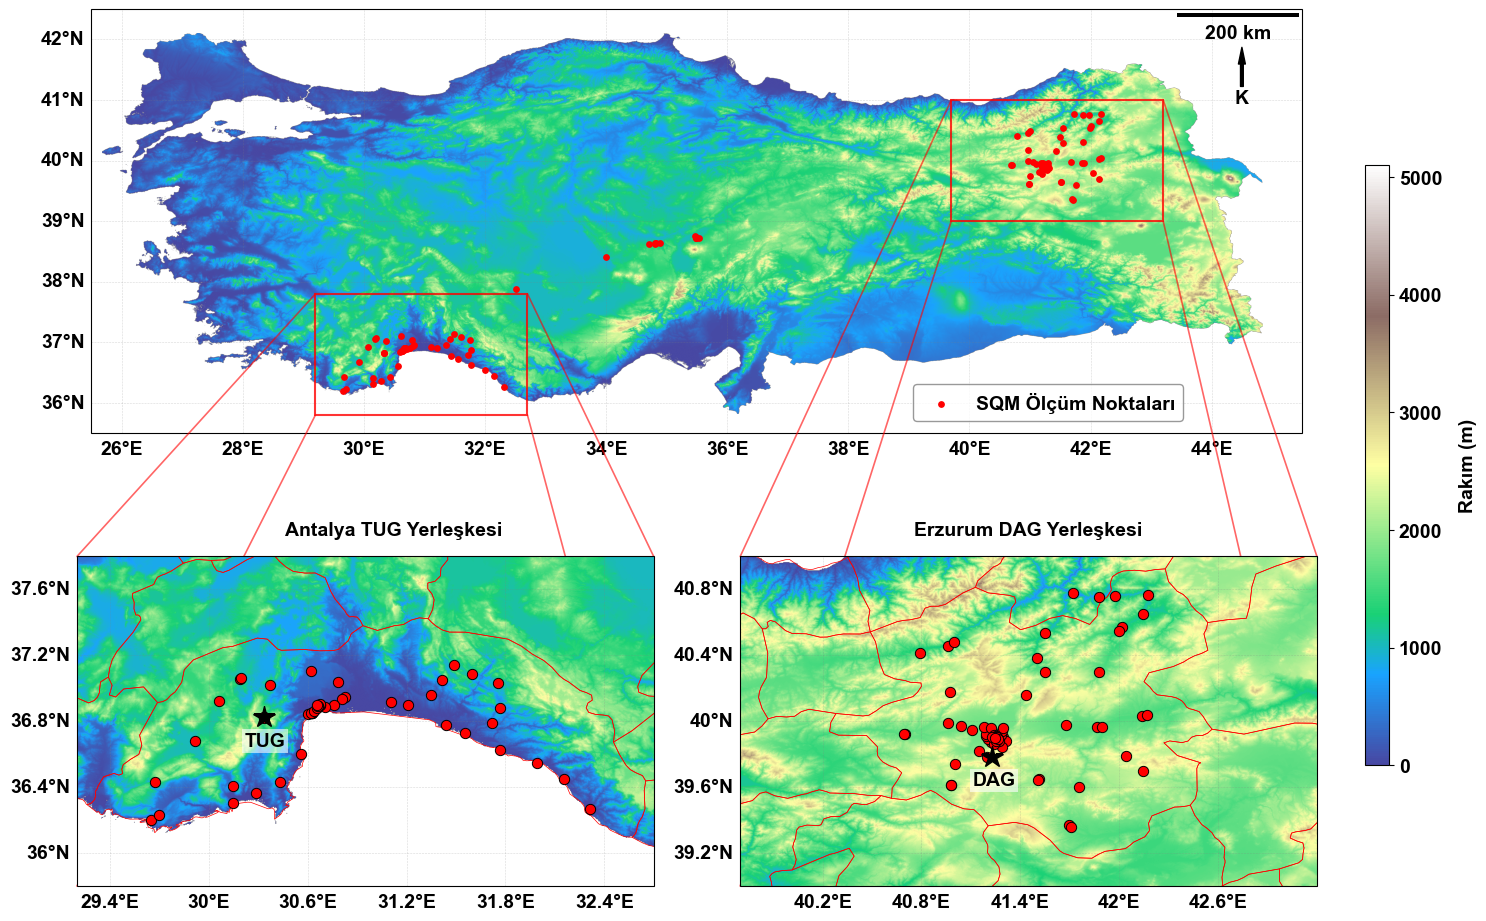

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
from matplotlib_scalebar.scalebar import ScaleBar
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# --- DİZİN VE DOSYA AYARLARI ---
base_dir = r'E:\=PROJELER\=TUBITAK_3501_2024\veri\uydu\dem'
dem_file = os.path.join(base_dir, 'SRTM_500m_Turkiye.tif')
out_dir = r'C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\sqm-viirs'

# SQM dosyalarından ölçüm konumlarının enlem ve boylam değerleri çekilecek
sqm_dir = r'E:\=PROJELER\=TUBITAK_3501_2024\veri\sqm\SQM_VERI_2025'
files = ['SQM_DUZENLI_VERI_ANTALYA.txt', 'SQM_DUZENLI_VERI_ERZURUM.txt', 'SQM_DUZENLI_VERI_TIKE.txt']

# --- VERİ OKUMA VE TEMİZLEME ---
all_data = []
for f in files:
    path = os.path.join(sqm_dir, f)
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        all_data.append(df)
    else:
        print(f"SONUC_RAPORU: UYARI - {f} dosyası '{sqm_dir}' dizininde bulunamadı!")

if len(all_data) == 0:
    raise FileNotFoundError(f"SONUC_RAPORU: HATA - Çizilecek hiçbir SQM veri dosyası bulunamadı! Yol: {sqm_dir}")

# Üç bölgedeki ölçüm noktalarını enlem ve boylam değerlerine göre birleştiriyoruz, Tekrar eden konumlar kaldırılıyor
df_all = pd.concat(all_data).drop_duplicates(subset=['Enlem (Derece)', 'Boylam (Derece)'])

# HARİTA AYARLARI (rcParams)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# --- HARİTA PANELLERİNİN OLUŞTURULMASI ---
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.18, wspace=0.15)

ax_tr = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
ax_ant = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax_erz = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())

# Sınırlar
tr_ext = [25.5, 45.5, 35.5, 42.5]
ant_ext = [29.2, 32.7, 35.8, 37.8] 
erz_ext = [39.7, 43.2, 39.0, 41.0]

axes = [ax_tr, ax_ant, ax_erz]
extents = [tr_ext, ant_ext, erz_ext]

# --- ÜLKE VE İL SINIRLARI ---
states_provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', facecolor='none')

# Antalya ve Erzurum il sınırları ekleniyor.
ax_ant.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='red')
ax_erz.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='red')

# --- DEM ÇİZİMİ ---
with rasterio.open(dem_file) as src:
    dem_data = src.read(1).astype(float)
    dem_data[dem_data <= 0] = np.nan 
    dem_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    for i, ax in enumerate(axes):
        ax.set_extent(extents[i])
        ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
        ax.add_feature(cfeature.LAND, facecolor='white', zorder=0)

        im = ax.imshow(dem_data, extent=dem_extent, transform=ccrs.PlateCarree(), cmap='terrain',
                       origin='upper', vmin=np.nanmin(dem_data), vmax=np.nanmax(dem_data), zorder=1, alpha=0.9)

# --- SQM NOKTALARI VE GÖZLEMEVLERİ ---
# Türkiye Haritası
ax_tr.scatter(df_all['Boylam (Derece)'], df_all['Enlem (Derece)'], color='red', s=15, transform=ccrs.PlateCarree(), zorder=10, label='SQM Ölçüm Noktaları')

# Detay Haritaları
for ax, ext, title in zip([ax_ant, ax_erz], [ant_ext, erz_ext], ['Antalya TUG Yerleşkesi', 'Erzurum DAG Yerleşkesi']):
    mask = (df_all['Boylam (Derece)'] >= ext[0]) & (df_all['Boylam (Derece)'] <= ext[1]) & \
           (df_all['Enlem (Derece)'] >= ext[2]) & (df_all['Enlem (Derece)'] <= ext[3])
    subset = df_all[mask]
    ax.scatter(subset['Boylam (Derece)'], subset['Enlem (Derece)'], color='red', s=55, edgecolors='black', linewidths=0.7, transform=ccrs.PlateCarree(), zorder=10)
    ax.set_title(title, pad=15, fontweight='bold')

# Antalya panel başlığının merkez konumunu
ax_ant.title.set_position([0.55, 1.0])

# Gözlemevleri (Yıldızlar)
ax_ant.plot(30.3353, 36.8243, '*', markerfacecolor='black', markersize=16,
            markeredgecolor='black', markeredgewidth=1.0, 
            transform=ccrs.PlateCarree(), zorder=12, label='Gözlemevi (TUG)')

ax_erz.plot(41.2264, 39.7809, '*', markerfacecolor='black', markersize=16,
            markeredgecolor='black', markeredgewidth=1.0,
            transform=ccrs.PlateCarree(), zorder=12, label='Gözlemevi (DAG)')

# Gözlemevleri (Etiket)
maske_stili = dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
ax_ant.text(30.22, 36.65, 'TUG', color='black', fontweight='bold', bbox=maske_stili, transform=ccrs.PlateCarree(), zorder=13)
ax_erz.text(41.11, 39.61, 'DAG', color='black', fontweight='bold', bbox=maske_stili, transform=ccrs.PlateCarree(), zorder=13)

# --- TR HARİTASINDA KUTULAR VE TÜM KÖŞE BAĞLANTILARI ---
# 1. Antalya (TUG) Bölgesi İçin Bağlantılar
inset_indicator1 = ax_tr.indicate_inset_zoom(ax_ant, edgecolor="red", alpha=0.8, lw=1.5, zorder=15)
# indicator nesnesi üzerinden bağlantı köşelerini çekiyoruz
connectors1 = inset_indicator1.connectors
connectors1[0].set_visible(True)
connectors1[1].set_visible(True)
connectors1[2].set_visible(True)
connectors1[3].set_visible(True)
for c in connectors1:
    c.set_linewidth(1.2)
    c.set_color('red')
    c.set_alpha(0.6)

# 2. Erzurum (DAG) Bölgesi İçin Bağlantılar
inset_indicator2 = ax_tr.indicate_inset_zoom(ax_erz, edgecolor="red", alpha=0.8, lw=1.5, zorder=15)
connectors2 = inset_indicator2.connectors
for c in connectors2:
    c.set_visible(True)
    c.set_linewidth(1.2)
    c.set_color('red')
    c.set_alpha(0.6)

# --- GRID, ETIKET VE KOORDİNAT FORMATI ---
# TR Haritası Grid
gl_tr = ax_tr.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.3, linestyle='--')
gl_tr.top_labels = gl_tr.right_labels = False
gl_tr.xlocator = mticker.MaxNLocator(integer=True)
gl_tr.ylocator = mticker.MaxNLocator(integer=True)
gl_tr.xformatter = LONGITUDE_FORMATTER
gl_tr.yformatter = LATITUDE_FORMATTER
gl_tr.xlabel_style = {'weight': 'bold'}
gl_tr.ylabel_style = {'weight': 'bold'}

# Bölge Haritaları Grid
for ax in [ax_ant, ax_erz]:
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xlocator = mticker.MaxNLocator(nbins=6) 
    gl.ylocator = mticker.MaxNLocator(nbins=6)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'weight': 'bold'}
    gl.ylabel_style = {'weight': 'bold'}

# Lejant Konumlandırması
geo_transform = ccrs.PlateCarree()._as_mpl_transform(ax_tr)
ax_tr.legend(loc='center', 
             bbox_to_anchor=(41.3, 36), 
             bbox_transform=geo_transform, 
             frameon=True, facecolor='white', framealpha=0.8, 
             edgecolor='gray')

# --- RENK ÇUBUĞU (Colorbar) ---
cbar_ax = fig.add_axes([0.93, 0.25, 0.015, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_yticks([0, 1000, 2000, 3000, 4000, 5000])
cbar.ax.tick_params()
cbar.set_label('Rakım (m)', weight='bold', labelpad=12)

# --- KUZEY OKU ---
x, y, arrow_length = 0.95, 0.91, 0.12
ax_tr.annotate('K', xy=(x, y), xytext=(x, y-arrow_length), color='black', size=14, weight='bold',
                arrowprops=dict(facecolor='black', width=2.0, headwidth=5),
                ha='center', va='center', xycoords=ax_tr.transAxes, zorder=20)

# Harita ölçeği
scalebar = ScaleBar(100, 'km', location= 'upper right', pad=0.1, border_pad=0.1, color='black', box_color='none')
ax_tr.add_artist(scalebar)

# Kayıt
output_path = os.path.join(out_dir, 'SONUC_RAPORU_SQM_01_calisma_alanlari-sqm_olcum_noktalari.png')
plt.savefig(output_path, dpi=500, bbox_inches='tight', facecolor='white')
print(f"Harita başarıyla kaydedildi: \n{output_path}")
plt.show()
plt.close()



## **1.4 SQM Veri Analizi ve Görselleştirilmesi**

## **1.4.1 Bölgesel Gökyüzü Kalitesinin Karşılaştırmalı Analizi**

- Düzenlediğimiz bütünleşik veri setlerinden gökyüzü parlaklığı değerlerinin görselleştirilmesi, her bölgenin yapay ışık kirliliğine maruz kalma derecesini ve karanlık gökyüzü rejimlerini mekânsal olarak anlamamızı sağlar.

- Bu bölümde; Antalya, Erzurum ve TİKE referans bölgelerine ait SQM ölçümlerini, astronomi standartlarında kabul gören Bortle ölçeği sınıflarına göre ayrıştırarak grafik üzerinde görselleştireceğiz.

- Aşağıdaki Python kodu; her üç bölgeyi dikey olarak hizalanmış alt panellerde sunacak, ilgili bölgelerin lokal aletsel ve çevresel parlamalardan kaynaklanan aykırı istasyonlarını filtreleyecek, değerleri artan gökyüzü karanlığına göre sıralayacak ve Bortle kalitesini temsil eden renk kuşağı arka planları (Pembe: Şiddetli Kirlilik, Sarı: Geçiş Bölgesi, Yeşil: Bozulmamış Karanlık Gökyüzü) üzerinde her rejimdeki istasyon sayılarıyla birlikte raporlayacaktır.


Sütun grafikleri kaydedildi: =cikti/sqm-viirs\SONUC_RAPORU_SQM_02_bortle_bolgesel_karsilastirma.png


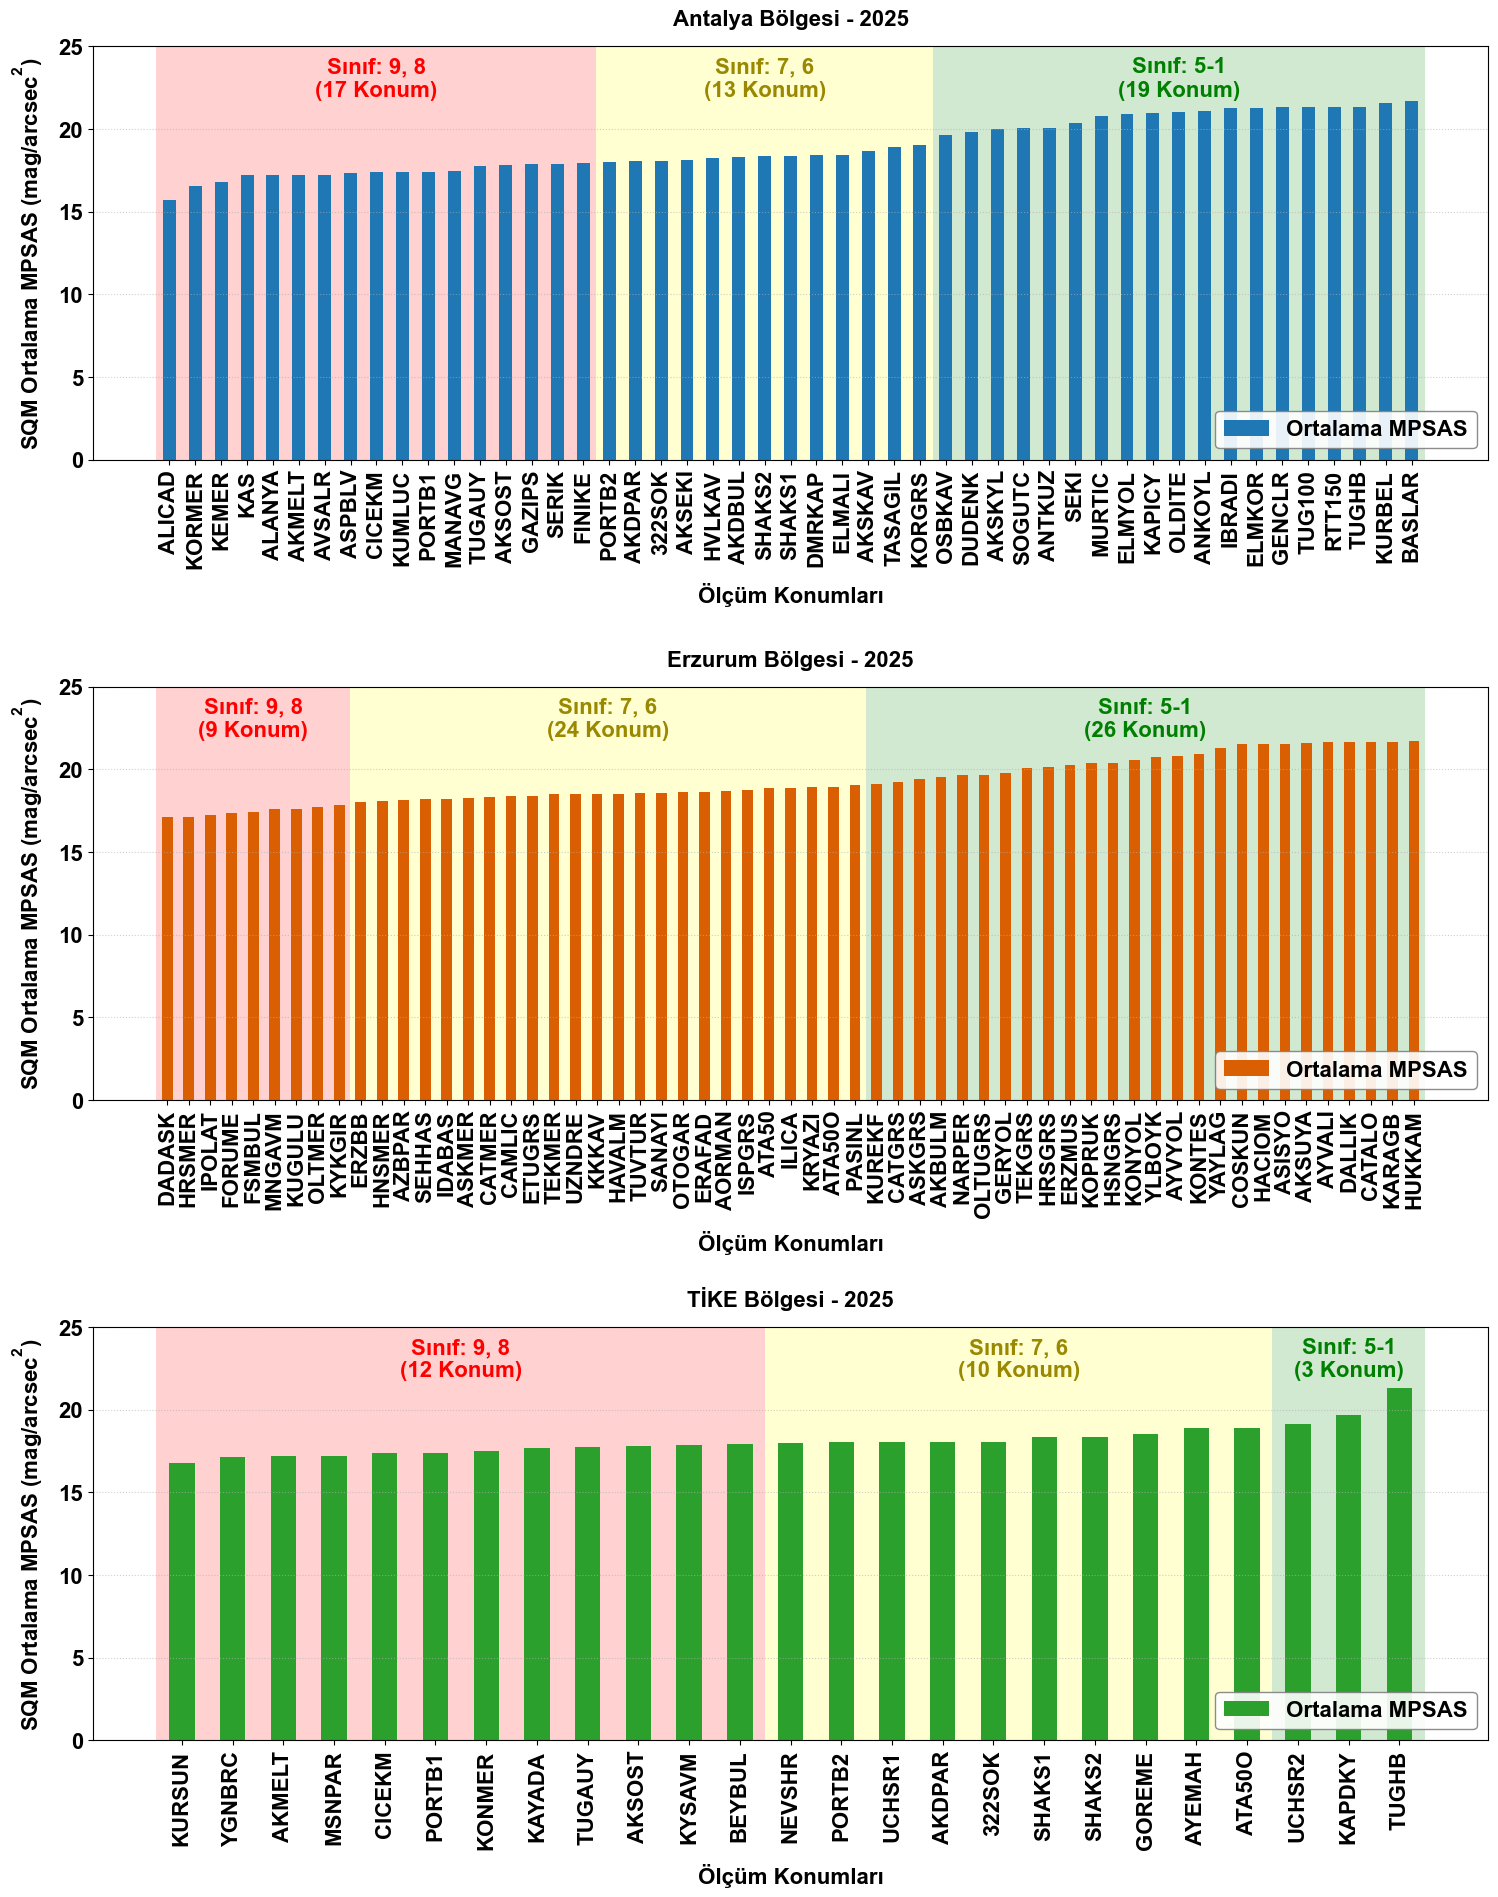

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# HARİTA AYARLARI (rcParams)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 16              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 16          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 16          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 16         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 16         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 16         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# Verilerin okunacağı ana dizin yolu
kaynak_dizin = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025'

# İşlenecek bölgeler ve bunlara ait parametreler
bolgeler = {
    'ANTALYA': {'dosya': 'SQM_DUZENLI_VERI_ANTALYA.txt', 'baslik': 'Antalya Bölgesi - 2025', 'renk': '#1f77b4'},
    'ERZURUM': {'dosya': 'SQM_DUZENLI_VERI_ERZURUM.txt', 'baslik': 'Erzurum Bölgesi - 2025', 'renk': '#d95f02'},
    'TIKE': {'dosya': 'SQM_DUZENLI_VERI_TIKE.txt', 'baslik': 'TİKE Bölgesi - 2025', 'renk': '#2ca02c'}
}

# figür boyutları 18x22 inç
fig, axs = plt.subplots(figsize=(18, 22), nrows=3, ncols=1, sharey=True)
plt.subplots_adjust(hspace=0.55) # Paneller arasındaki dikey boşluk

for idx, (anahtar, params) in enumerate(bolgeler.items()):
    ax = axs[idx]
    
    # Verinin okunması
    dosya_yolu = os.path.join(kaynak_dizin, params['dosya'])
    sqm_veri = pd.read_csv(dosya_yolu, delimiter='\t')
    
    # Her bölge için aykırı değerleri temizliyoruz
    if anahtar in ['ANTALYA', 'TIKE']:
        sqm_veri = sqm_veri[~sqm_veri['Konum'].isin(['BELEDC', 'CAGMR1', 'CAGMR2'])]
    elif anahtar == 'ERZURUM':
        sqm_veri = sqm_veri[~sqm_veri['Konum'].isin(['ISPMER', 'ABDURG', 'TORTUK', 'DAGREZ'])]
        
    sqm_veri = sqm_veri.set_index(['Konum'])
    veri_sirali = sqm_veri.sort_values(by=['Ortalama_MPSAS (mag/arcsec^2)'])
    
    # Bar çizimi
    ax.bar(veri_sirali.index, veri_sirali['Ortalama_MPSAS (mag/arcsec^2)'], color=params['renk'], width=0.5, alpha=1.0, label='Ortalama MPSAS')
    
    # Bortle sınıflarının hesaplanması
    bortle_sinif_15 = veri_sirali[veri_sirali['Ortalama_MPSAS (mag/arcsec^2)'] >= 19.10]
    bortle_sinif_67 = veri_sirali[(veri_sirali['Ortalama_MPSAS (mag/arcsec^2)'] >= 18.00) & (veri_sirali['Ortalama_MPSAS (mag/arcsec^2)'] < 19.10)]
    bortle_sinif_89 = veri_sirali[veri_sirali['Ortalama_MPSAS (mag/arcsec^2)'] < 18.00]
    
    sayi_15 = len(bortle_sinif_15)
    sayi_67 = len(bortle_sinif_67)
    sayi_89 = len(bortle_sinif_89)
    
    # Arka plan Bortle kalite kuşaklarının (axvspan) çizilmesi
    ax.axvspan(-0.5, sayi_89 - 0.5, facecolor='red', alpha=0.18, zorder=0)
    ax.axvspan(sayi_89 - 0.5, sayi_89 + sayi_67 - 0.5, facecolor='yellow', alpha=0.18, zorder=0)
    ax.axvspan(sayi_89 + sayi_67 - 0.5, sayi_89 + sayi_67 + sayi_15 - 0.5, facecolor='green', alpha=0.18, zorder=0)
    
    # Bortle ölçek bilgi metinlerinin yazdırılması
    veri_maksimum_deger = 22.0
    ax.text(max(0, (sayi_89-1)/2),  veri_maksimum_deger, f'Sınıf: 9, 8\n({sayi_89} Konum)', ha='center', color='red', weight='bold')
    ax.text(sayi_89 + max(0, (sayi_67-1)/2), veri_maksimum_deger, f'Sınıf: 7, 6\n({sayi_67} Konum)', ha='center', color='#998800', weight='bold')
    ax.text(sayi_89 + sayi_67 + max(0, (sayi_15-1)/2), veri_maksimum_deger, f'Sınıf: 5-1\n({sayi_15} Konum)', ha='center', color='green', weight='bold')
    
    # Grafik detay ayarları
    ax.set_title(params['baslik'], fontweight='bold', pad=15)
    ax.set_ylabel('SQM Ortalama MPSAS ($mag/arcsec^2$)', fontweight='bold', labelpad=10)
    ax.set_xlabel('Ölçüm Konumları', fontweight='bold', labelpad=10)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # Konum isimlerinin (X ekseni) ayarları
    ax.set_xticklabels(veri_sirali.index, rotation=90, fontweight='bold')
    
    # Y ekseni sayı boyutları
    ax.tick_params(axis='y')
    ax.set_ylim([0, 25])
    
    # Lejant ayarları
    ax.legend(loc='lower right', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

# Çıktı klasörünü kontrol edip yok ise oluşturuyoruz
cikti_klasoru = '=cikti/sqm-viirs'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)

# Bütünleşik çoklu görseli yüksek çözünürlükte kaydediyoruz
cikti_yolu = os.path.join(cikti_klasoru, 'SONUC_RAPORU_SQM_02_bortle_bolgesel_karsilastirma.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight', facecolor='white')
print(f"Sütun grafikleri kaydedildi: {cikti_yolu}")
plt.show()
plt.close()



## **1.4.2 TİKE Projesi Konumlarında Işık Kirliliğinin Değişimi**

- Gece gökyüzü parlaklığındaki değişimler, zamandan bağımsız durağan bir çevre sorunu olmayıp; hızlı nüfus artışı, kontrolsüz kentsel yayılma, turizm faaliyetleri ve yanlış aydınlatma uygulamalarıyla sürekli evrilen dinamik bir süreçtir. Bu bölümde, İç Anadolu Bölgesi'nde yer alan referans istasyonlarımızdaki (Kayseri, Nevşehir, Aksaray ve Konya) ışık kirliliğinin son 15 yıldaki zamansal gelişimini nicel olarak değerlendireceğiz.

- Bu analiz kapsamında, Türkiye'de şık kirliliği konusunda en önemli erken dönem yer tabanlı çalışmalardan biri olan ve **"Türkiye'de Işık Kirliliğini Engelleme - TİKE"** projesinin referans ölçüm değerlerini (2010–2013), 2025 yılı yaz aylarında aynı istasyonları yeniden ziyaret ederek gerçekleştirdiğimiz güncel saha ölçüm verileriyle karşılaştıracağız.

- Yazacağımız Python kodu; her iki dönem verisini istasyon kodlarına göre çakıştıracak, aradaki farkları hesaplayacak ve iki renkli dikey sütun grafiği üzerinden hangi referans noktalarının doğal karanlığını koruyabildiğini, hangi bölgelerin ise yoğun insan kaynaklı yapay ışık artışına maruz kalarak gökyüzü kalitesini yitirdiğini doğrudan ortaya koyacaktır. Bu karşılaştırma, bölgedeki imar ve aydınlatma politikalarının on yıllık kümülatif etkisini anlamamız için kritik bir yer gerçekliği tabanı sağlayacaktır.


TİKE değişim grafiği kaydedildi: 
=cikti/sqm-viirs\SONUC_RAPORU_SQM_03_tike_isik_kirliligi_degisimi.png


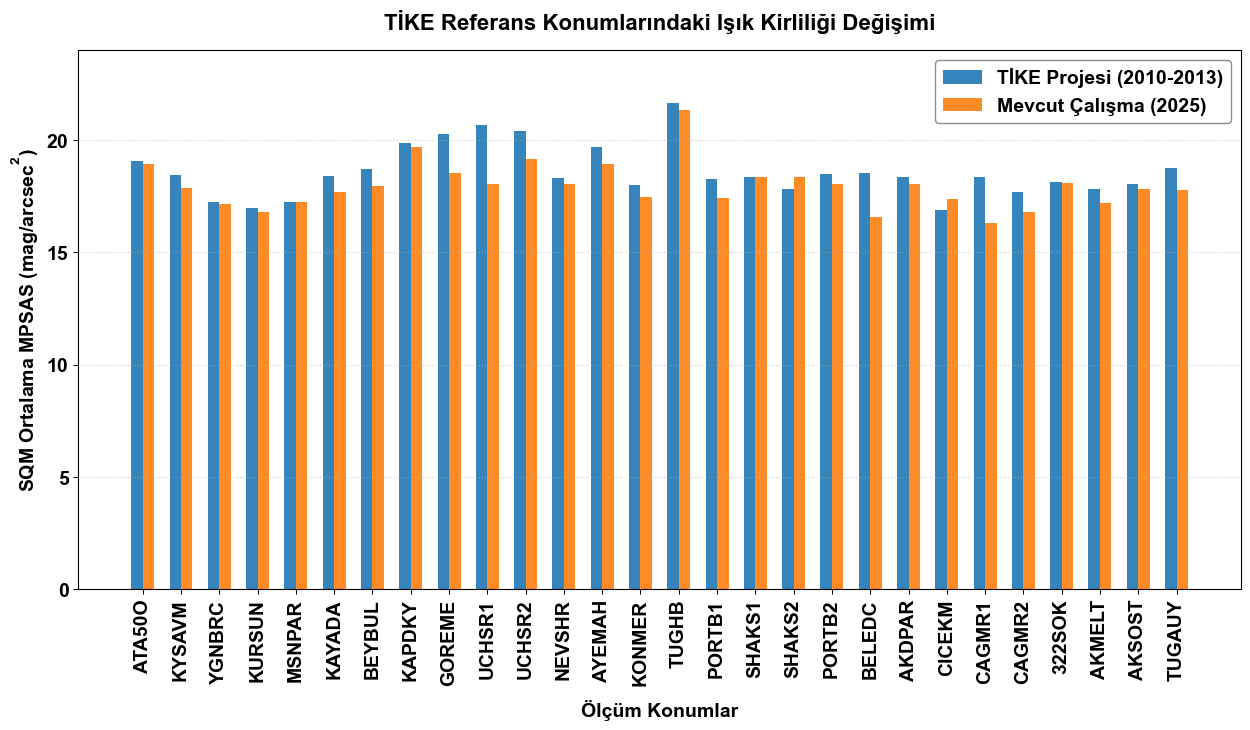

In [1]:

# Gerekli kütüphaneleri içe aktarıyoruz
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# HARİTA AYARLARI (rcParams)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 16          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# Veri Okuma
dosya_yolu = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025\\TIKE_degisim.txt'
sqm_veri = pd.read_csv(dosya_yolu, delimiter='\t', encoding='unicode_escape')

fig, ax = plt.subplots(figsize=(15, 7), nrows=1, ncols=1)

# X ekseni indis dizisi tanımlanıyor
w, x = 0.3, np.arange(len(sqm_veri))

# Bar Grafiklerinin Çizilmesi
ax.bar(x - w/2, sqm_veri['Tike Ölçümleri'], width=w, label='TİKE Projesi (2010-2013)', color='#1f77b4', alpha=0.9)
ax.bar(x + w/2, sqm_veri['Ortalama_MPSAS (mag/arcsec^2)'], width=w, label='Mevcut Çalışma (2025)', color='#ff7f0e', alpha=0.9)

# Eksen başlıkları yazdırılıyor
ax.set_ylabel('SQM Ortalama MPSAS ($mag/arcsec^2$)', fontweight='bold')
ax.set_xlabel('Ölçüm Konumlar', fontweight='bold', labelpad=10)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Konum isimlerinin (X ekseni) yazı tipi kalın (bold) yapılmıştır.
plt.xticks(x, sqm_veri['Konum'], rotation=90, fontweight='bold')
plt.ylim([0, 24])

# Lejant Konumlandırması (Sağ üst)
plt.legend(loc='upper right', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

# Grafik Başlığı
plt.title('TİKE Referans Konumlarındaki Işık Kirliliği Değişimi', weight='bold', pad=15)

# Kayıt işlemleri
cikti_klasoru = '=cikti/sqm-viirs'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)
    
cikti_yolu = os.path.join(cikti_klasoru, 'SONUC_RAPORU_SQM_03_tike_isik_kirliligi_degisimi.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight', facecolor='white')

print(f"TİKE değişim grafiği kaydedildi: \n{cikti_yolu}")
plt.show()
plt.close()



## **1.5 Bölüm Özeti**

Bu eğitim ve uygulama dosyasında, Türkiye'nin iki büyük astronomik araştırma tesisine ev sahipliği yapan Antalya (TUG) ve Erzurum (DAG) illeri ile İç Anadolu referans istasyonlarındaki (TİKE) yer tabanlı gökyüzü parlaklığı verilerinin işlenmesi, görselleştirilmesi ve analiz edilmesi süreçleri gerçekleştirilmiştir.

**1. Veri Düzenleme**

- Saha çalışmaları sırasında kaydedilen, istasyon bazlı ve yapılandırılmamış durumdaki .dat dosyaları Python ortamına aktarılmıştır.

- Her bir dosyanın meta verilerinden enlem, boylam ve rakım bilgileri ayıklanmıştır. Ölçüm protokolüne uygun olarak, sensörün ısınma ve stabilizasyon hatalarını barındıran ilk iki saniye bazlı veri elenmiş; geriye kalan kararlı durumdaki 10 okumanın aritmetik ortalaması alınarak nihai gökyüzü parlaklığı ($mag/arcsec^2$) hesaplanmıştır.

- Coğrafi Bilgi Sistemleri (CBS) ve haritalama yazılımlarıyla tam uyumluluk sağlamak amacıyla, enlem ve boylam koordinatları virgülden sonra tam olarak 6 hane hassasiyetinde, diğer sayısal parametreler ise 2 hane olarak dikey bir tabloda birleştirilmiş ve her bölge için tek bir bütünleşik zaman serisi dosyası (txt) olarak kaydedilmiştir.

**2. Mekânsal Dağılım ve Çalışma Alanı Haritasının Üretilmesi**

- Ölçüm koordinatları, SRTM 500m Sayısal Yükseklik Modeli (DEM) altlığı üzerine Cartopy ve Matplotlib kütüphaneleri kullanılarak haritalandırılmıştır.

- Tüm noktaların dağılımı ile Antalya (TUG) ve Erzurum (DAG) yerleşkelerinin yakın plan görünümleri üç panelli tek bir şekilde birleştirilmiştir.

**3. Bölgesel Gökyüzü Kalitesi ve Bortle Sınıflandırması**

- Analizlerin güvenirliğini düşürecek olan aykırı değerler veriden sistematik olarak temizlenmiştir (BELEDC, CAGMR1, CAGMR2, ISPMER, ABDURG, TORTUK, DAGREZ).

- Ölçüm istasyonları, gökyüzü parlaklığı değerlerine göre artan karanlık sırasında sıralanmış ve Bortle ölçeğine göre sınıflandırılmıştır.

- Üç bölgenin (Antalya, Erzurum, TİKE) frekans dağılımları tek bir bütünleşik bar grafiği üzerinde sunulmuştur.

**4. TİKE Konumlarında Zamansal Değişim ve Işık Kirliliği İvmesi**

- İç Anadolu Bölgesi'ndeki (Kayseri, Nevşehir, Aksaray ve Konya) 28 referans noktası, 15 yıllık bir aradan sonra yeniden ölçülerek karşılaştırılmıştır.

- Bu zamansal analiz, ışık kirliliğinin durağan bir çevre sorunu olmadığını, aksine hızla genişleyen dinamik bir tehdit olduğunu kanıtlamış; ışık kirliliği azaltma politikalarının uygulamaya koyulmasına dair bilimsel bir eylem çağrısı üretmiştir.



## **Yapay Zeka Kullanım Beyanı**

- Bu çalışmanın Python kodlarının geliştirilmesi, veri analiz algoritmalarının optimizasyonu, İngilizce-Türkçe akademik çeviriler ve raporlama süreçlerinde yapay zeka asistanından (Google Gemini) teknik ve dilsel destek alınmıştır. Çalışmanın bilimsel doğruluğu, veri bütünlüğü ve nihai raporlama sorumluluğu tamamen araştırmacılara aittir.



- **Kaynak:**

Kaba, K., Aydın, S., Türkmen, R. B., Polat, F., Aksoy, F., Nasıroğlu, İ., Yeşilyaprak, C., Kandırmaz, H. M.  (2026b). Long-term dynamics and machine learning-based mapping of night sky brightness: snowglow, urbanization, and topography effects at major astronomical observatories in Türkiye. Experimental Astronomy, 62, 16. https://doi.org/10.1007/s10686-026-10076-6
